Chart saved as 'building_condition_chart.png'


<Figure size 1400x700 with 0 Axes>

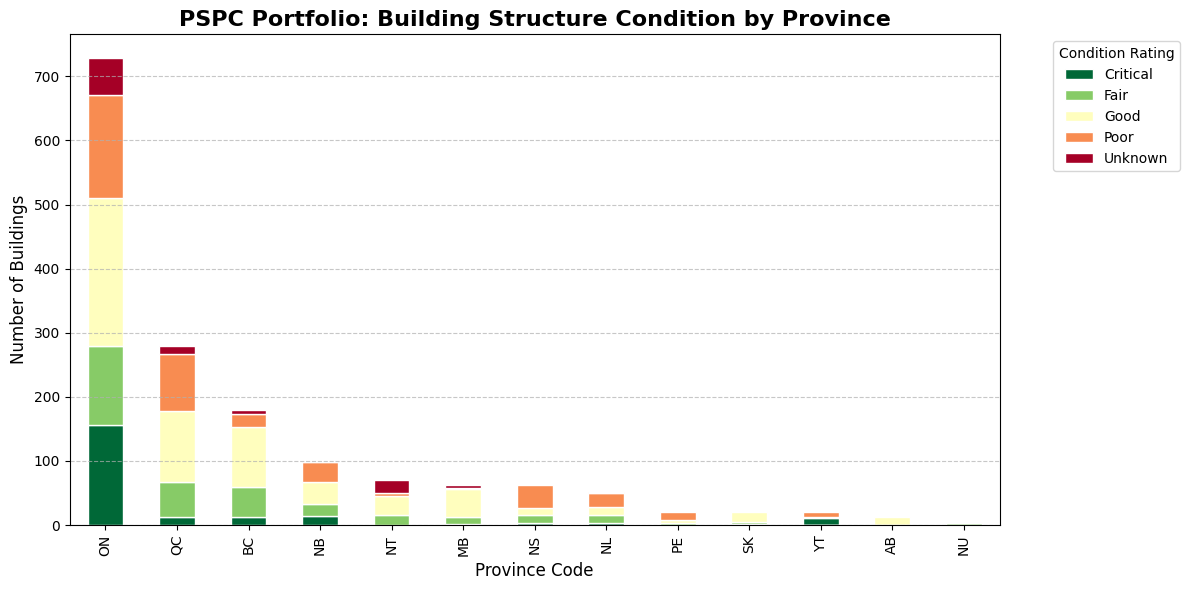

In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# 1. Load the Building Condition dataset
# Note: Using 'latin1' encoding to handle French characters in the CSV
file_path = 'immeubleetatadequat-buildingfaircondition.csv'
df = pd.read_csv(file_path, encoding='latin1')

# 2. Prepare the data
# We group by Province and Condition to count the number of assets in each category
condition_pivot = df.groupby(['Province-Code_Code-de-province', 
                                'Structure-condition_condition-de-la-structure-ENG']).size().unstack().fillna(0)

# Sort provinces by total number of buildings so the chart is easier to read
condition_pivot['Total'] = condition_pivot.sum(axis=1)
condition_pivot = condition_pivot.sort_values(by='Total', ascending=False).drop(columns='Total')

# 3. Create the Visualization
plt.figure(figsize=(14, 7))

# We use a stacked bar chart to show the mix of "Good" vs "Critical" assets per region
# 'RdYlGn_r' is a good colormap here as it shows Red for Critical/Poor and Green for Good
condition_pivot.plot(kind='bar', 
                     stacked=True, 
                     figsize=(12, 6), 
                     colormap='RdYlGn_r', 
                     edgecolor='white')

plt.title('PSPC Portfolio: Building Structure Condition by Province', fontsize=16, fontweight='bold')
plt.xlabel('Province Code', fontsize=12)
plt.ylabel('Number of Buildings', fontsize=12)
plt.legend(title='Condition Rating', bbox_to_anchor=(1.05, 1), loc='upper left')
plt.grid(axis='y', linestyle='--', alpha=0.7)

plt.tight_layout()
plt.savefig('building_condition_chart.png')
print("Chart saved as 'building_condition_chart.png'")